# Demo — Predict only (use a shipped cardiac classifier)

This is the recommended first-touch notebook for TissueTypist. It runs
**prediction only**, using one of the shipped pre-trained cardiac
presets. No training step.

The shipped `default` preset was trained on Visium SD (3-prime + FFPE)
and Visium HD reference data; you can apply it to any Visium SD query
without retraining.

If your query is from an imaging-based platform (Xenium / MERFISH /
CosMx) where the gene panel is much smaller than the reference, you
need to **retrain on the panel** instead — see `demo_merfish.ipynb`.


**Data used here.** 
- VisiumSD cardiac AnnData (17 sections) [Lázár E et al., Nat Genet, 2025](https://www.nature.com/articles/s41588-025-02352-6)
   * The original Seurat object is [here](https://data.mendeley.com/datasets/w65jtfsvpr/1)
   * The converted anndata object which is used in this notebook is [here](https://www.dropbox.com/scl/fi/n4odowubogr4vxlnuvmb1/Lazar2025_HDCA_heart_clustering_converted.h5ad?rlkey=hm6vn7i75mo52argyp2ozgfog&st=tgmk1y3o&dl=0)

## 1. Setup

In [1]:
# Edit this path to point at your query Visium AnnData (raw counts in adata.X).
from pathlib import Path

QUERY     = ".../.../Lazar2025_HDCA_heart_clustering_converted.h5ad"   # ← change here
OUTDIR    = Path("results/predict_only_demo")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Optional: pick a preset other than "default" — alternatives are
# "own_only" (no neighbour features) and "neighbour_heavy".
PRESET    = "default"


In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import tissuetypist
from tissuetypist import predict_adata, load_preset

print("TissueTypist version:", tissuetypist.__version__)
print("Preset:", PRESET, "→", load_preset(PRESET))


TissueTypist version: 0.1.0
Preset: default → /Users/kazumasakanemaru/GitHub/TissueTypist/tissuetypist/models/default


## 2. Load and inspect the query

Required:

- **Raw counts in `adata.X`** (no log-normalisation — TissueTypist handles
  this automatically based on dtype heuristics).
- **`obsm['spatial']`** — 2-D coordinates per spot.
- **`obs[section_col]`** — a section / library identifier; spots from
  different sections must not share coordinates.


In [3]:
adata = sc.read_h5ad(QUERY)
print(adata)
print()
print("var_names:", adata.var_names[:5].tolist(), "...")
print("obs columns:", adata.obs.columns.tolist())


AnnData object with n_obs × n_vars = 25309 × 17219
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'section.name', 'age', 'id', 'labels', 'percent.mt', 'percent.ribo', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'seurat_clusters_annot', 'sample_id', 'original_obsnames', 'in_tissue', 'array_row', 'array_col', 'pxl_col_in_fullres', 'pxl_row_in_fullres'
    obsm: 'spatial'

var_names: ['SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1'] ...
obs columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'section.name', 'age', 'id', 'labels', 'percent.mt', 'percent.ribo', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'seurat_clusters_annot', 'sample_id', 'original_obsnames', 'in_tissue', 'array_row', 'array_col', 'pxl_col_in_fullres', 'pxl_row_in_fullres']


In [4]:
# Pick the section column. Check `adata.obs.columns` if `section_ID`
# isn't the right one for your dataset.
SECTION_COL = "section.name"

n_spots_per_section = adata.obs[SECTION_COL].value_counts()
print(n_spots_per_section)


section.name
V10T03-309_C1    2935
V11A20-401_D1    2730
V11A20-401_C1    2534
V10F24-105_C1    2233
V10F24-105_B1    2223
V11A20-401_A1    1660
V11A20-401_B1    1638
V10A13-157_C1    1543
V10A13-157_D1    1506
V10A13-157_B1    1073
V10A13-157_A1    1069
V10T03-311_C1     877
V10A13-160_C1     743
V10A13-160_D1     716
V10T03-311_B1     639
V10A13-160_A1     615
V10A13-160_B1     575
Name: count, dtype: int64


## 3. Run prediction

In [5]:
adata = predict_adata(
    adata,
    model_dir=load_preset(PRESET),
    modality="sd",                 # "sd" for Visium SD; "hd" for Visium HD windows
    section_col=SECTION_COL,
)

# All output is written into adata.obs as `tt_*` columns.
tt_cols = [c for c in adata.obs.columns if c.startswith("tt_")]
print(f"{len(tt_cols)} tt_* columns added: {tt_cols}")


27 tt_* columns added: ['tt_coarse_label', 'tt_coarse_score', 'tt_fine_label', 'tt_fine_score', 'tt_joint_score', 'tt_final_label', 'tt_low_conf', 'tt_stage2a_score', 'tt_vasc2a_score', 'tt_ventricle_label', 'tt_ventricle_score', 'tt_avjunction_label', 'tt_avjunction_score', 'tt_atrium_split_label', 'tt_atrium_split_score', 'tt_atrium_transitional_label', 'tt_atrium_transitional_score', 'tt_atrium_lr_label', 'tt_atrium_lr_score', 'tt_pcs_split_label', 'tt_pcs_split_score', 'tt_pcs_sinoatrial_label', 'tt_pcs_sinoatrial_score', 'tt_vasc_split_label', 'tt_vasc_split_score', 'tt_vasc_fine_label', 'tt_vasc_fine_score']


## 4. Inspect predictions

`tt_final_label` is the recommended per-spot label (the finest class
that resolved confidently). `tt_coarse_score` is the confidence of the
coarse-level prediction.


In [8]:
# Top labels by spot count
print(adata.obs["tt_final_label"].value_counts())


tt_final_label
Ventricle - Compact            11655
Ventricle - Trabeculated        4350
Atrium - Left                   2282
Great vessel                    1724
VCS - Proximal                  1142
Endocardium - Ventricular       1062
VCS - Distal                     676
Ventricle                        512
Epicardial region                488
Endocardium - Atrial             370
Endocardial cushion - Valve      230
Atrium - Right                   229
Connective tissue                199
AV ring                          179
AV nodal region                   77
Atrium                            54
AV junction                       26
Vasculature                       21
Pacemaker conduction system       13
Ductus arteriosus                 12
Coronary vessel                    6
SA node - Tail                     2
Name: count, dtype: int64


In [9]:
# Save the predictions for downstream use
out_h5ad = OUTDIR / "predicted.h5ad"
adata.write_h5ad(out_h5ad)
print(f"Saved → {out_h5ad}")

# CSV summary of just the obs predictions
out_csv = OUTDIR / "predictions.csv.gz"
cols = [SECTION_COL] + tt_cols
adata.obs[cols].to_csv(out_csv, index=True)
print(f"Saved → {out_csv}")


Saved → results/predict_only_demo/predicted.h5ad
Saved → results/predict_only_demo/predictions.csv.gz


## 5. Spatial plot

In [16]:
palette = {
    'Atrium - Left': '#1f77b4',
    'Atrium - Right': '#ff7f0e',
    'Atrium - Transitional': '#2ca02c',

    'Sinus horn': '#d62728',
    'SA node - Head': '#9467bd',
    'SA node - Tail': '#8c564b',
    'AV nodal region': '#e377c2',

    'Endocardial cushion - Valve': '#7f7f7f',

    'Ventricle - Compact': '#bcbd22',
    'Ventricle - Trabeculated': '#17becf',

    'VCS - Proximal': '#aec7e8',
    'VCS - Distal': '#ffbb78',

    'Endocardium - Atrial': '#c7e9c0',
    'Endocardium - Ventricular': '#98df8a',

    'Great vessel': '#ff9896',
    'Ductus arteriosus': '#c5b0d5',
    'Coronary vessel': '#c49c94',

    'Connective tissue': '#f7b6d2',
    'Epicardial region': '#c7c7c7',
    'Lymph node': '#9edae5',

    'Atrial myocardium': '#1f77b4',
    'Sinoatrial region': '#d62728',   # same as Sinus horn (region-level proxy)
}

palette.update({

    # ---- Higher-level / umbrella ----
    'Atrium': '#6baed6',            # lighter blue (parent of L/R)
    'Ventricle': '#9ecae1',         # light blue counterpart

    # ---- AV / conduction system extensions ----
    'AV junction': '#db7093',       # between AV node (pink) and surrounding tissue
    'AV ring': '#f7b6d2',           # related to connective / fibrous ring
    'Pacemaker conduction system': '#c51b8a',  # stronger magenta (parent class)

    # ---- Vascular system ----
    'Vasculature': '#9edae5',       # reuse lymph-node-like soft cyan (system-level)
})

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


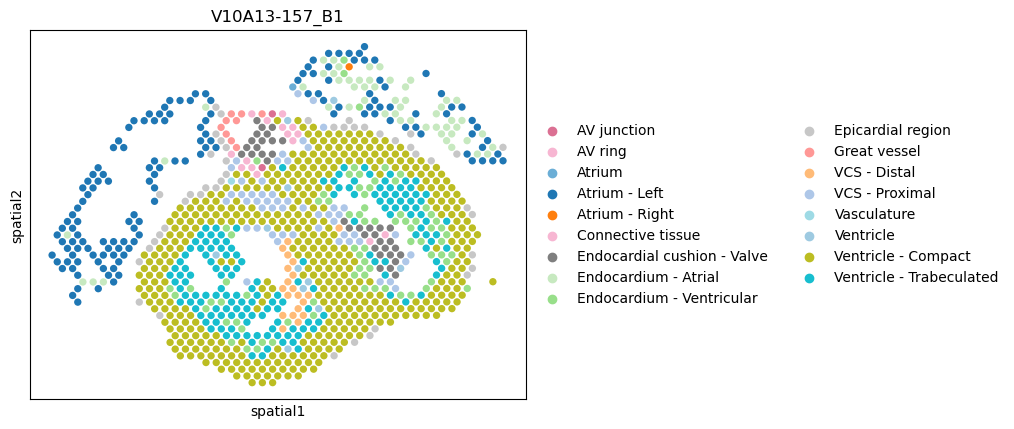

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


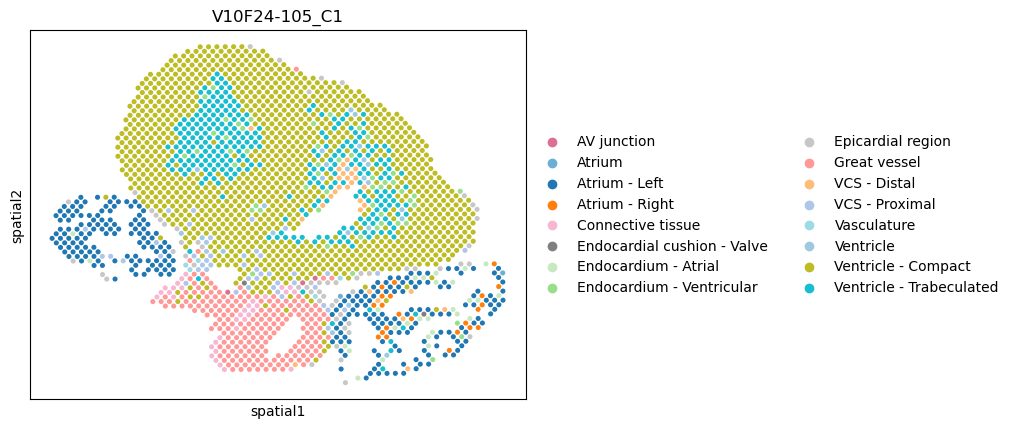

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


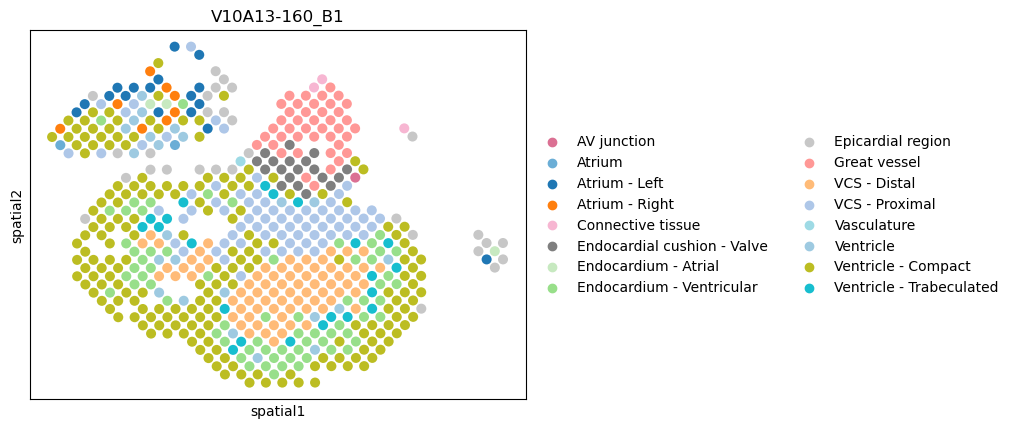

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


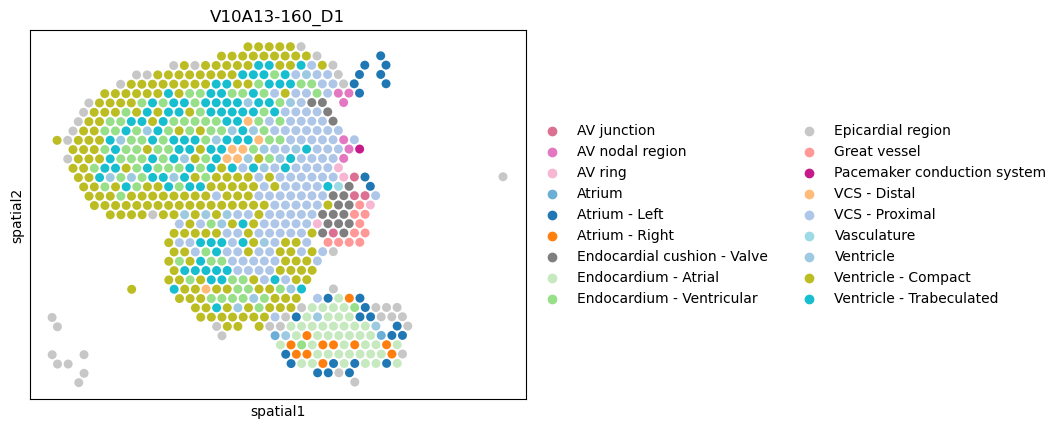

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


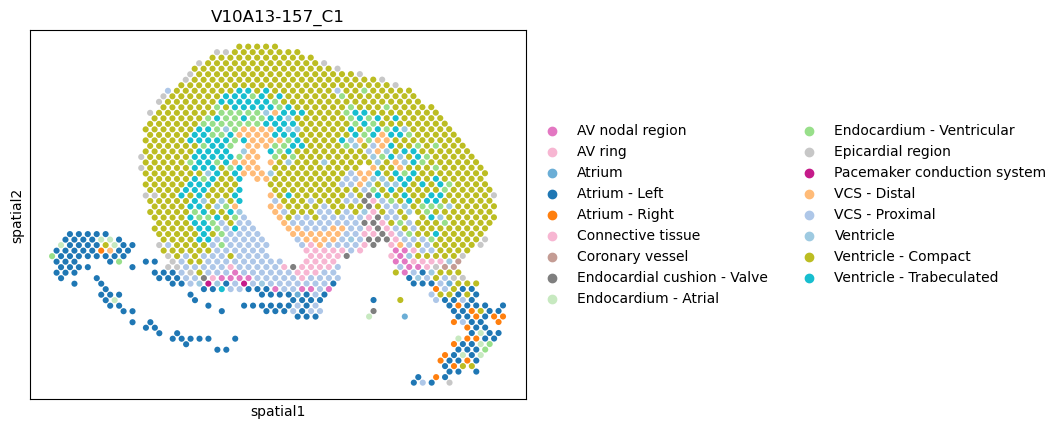

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


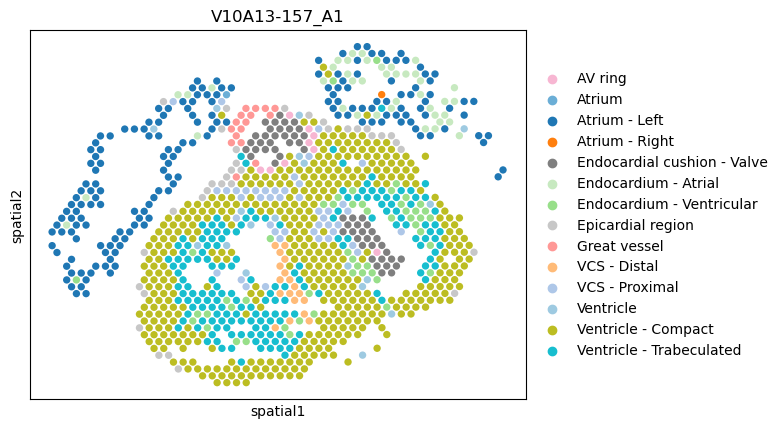

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


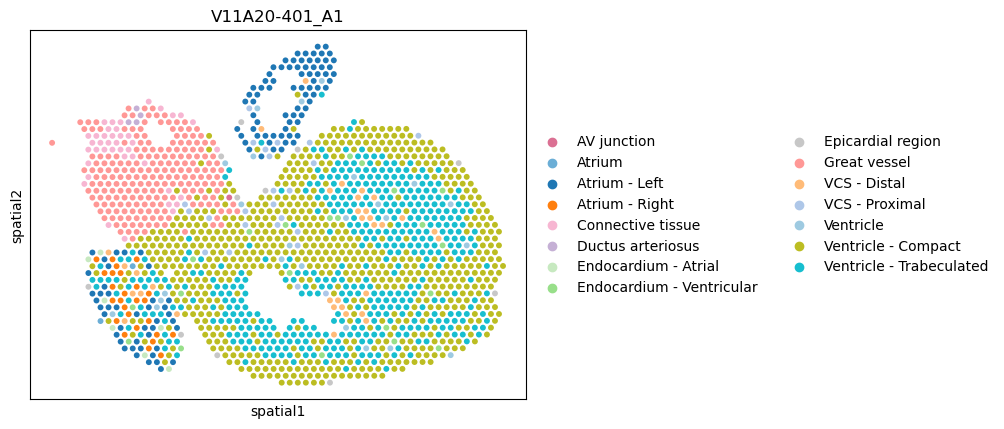

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


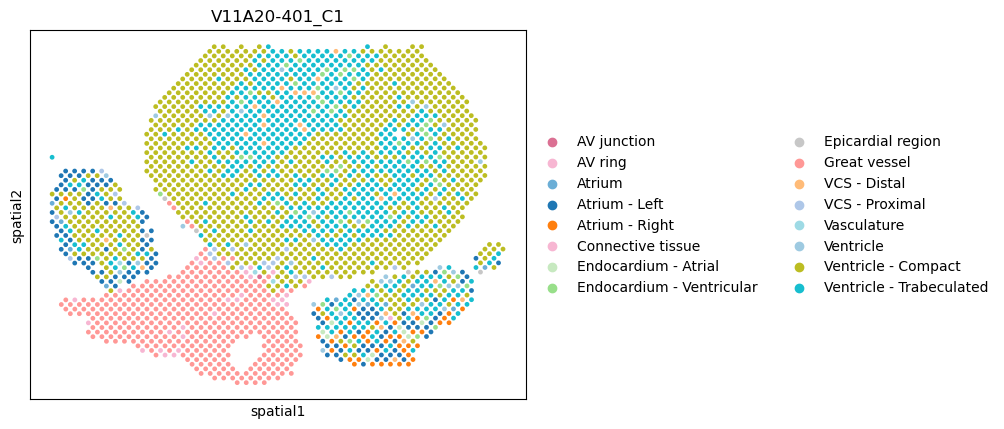

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


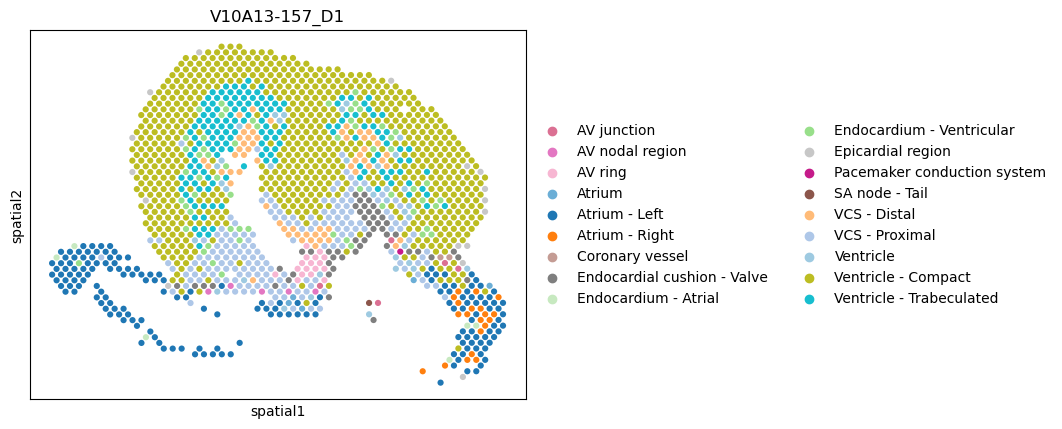

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


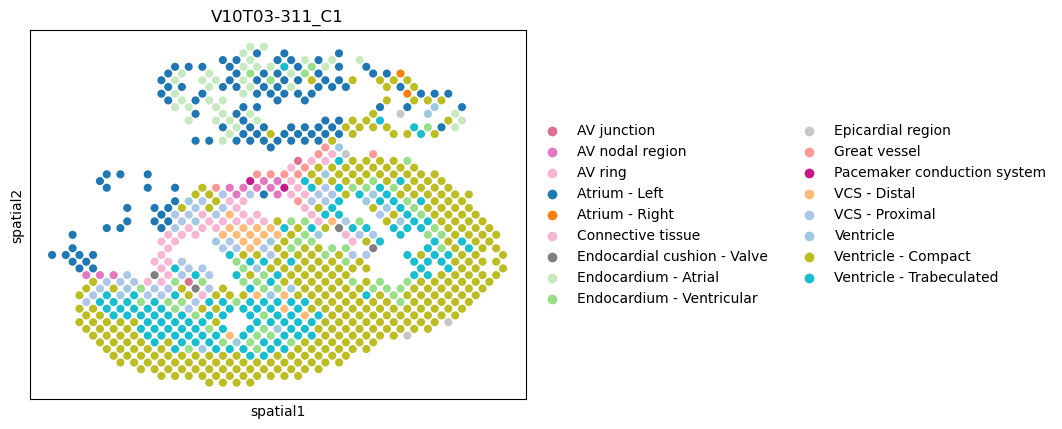

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


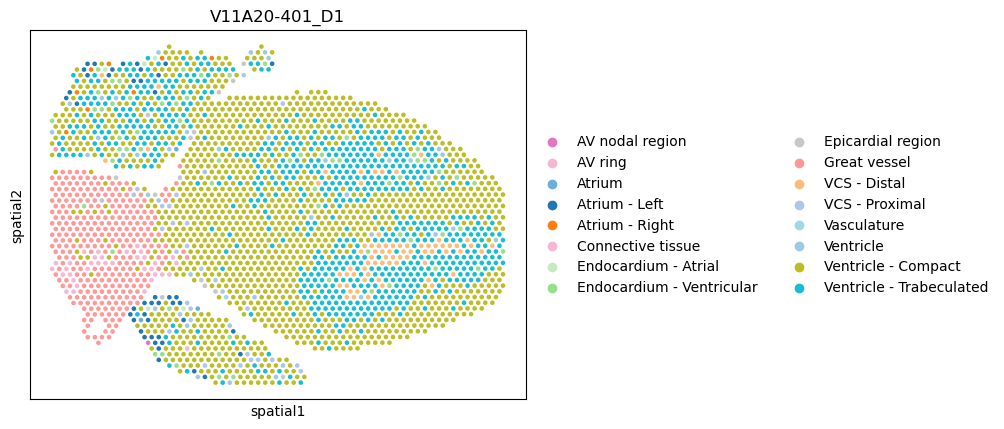

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


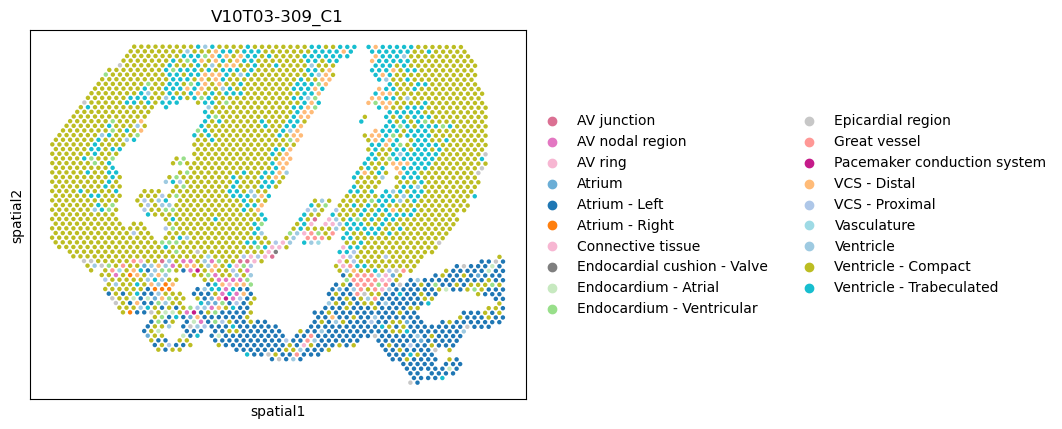

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


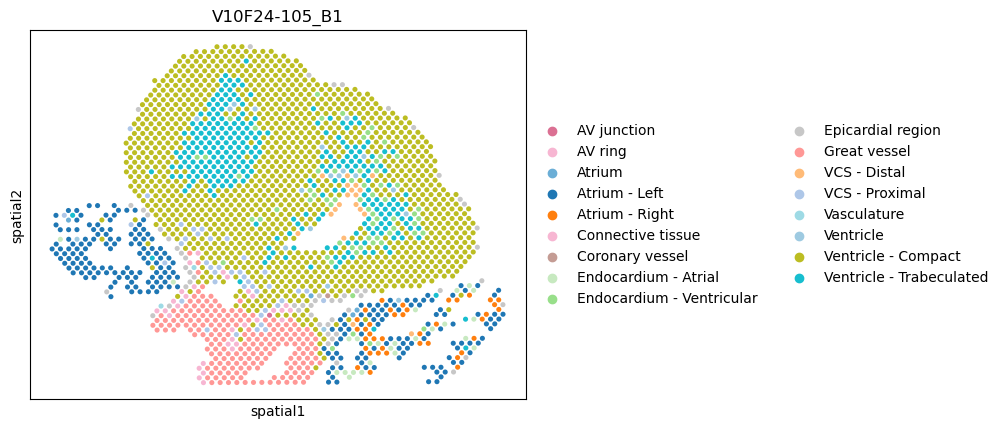

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


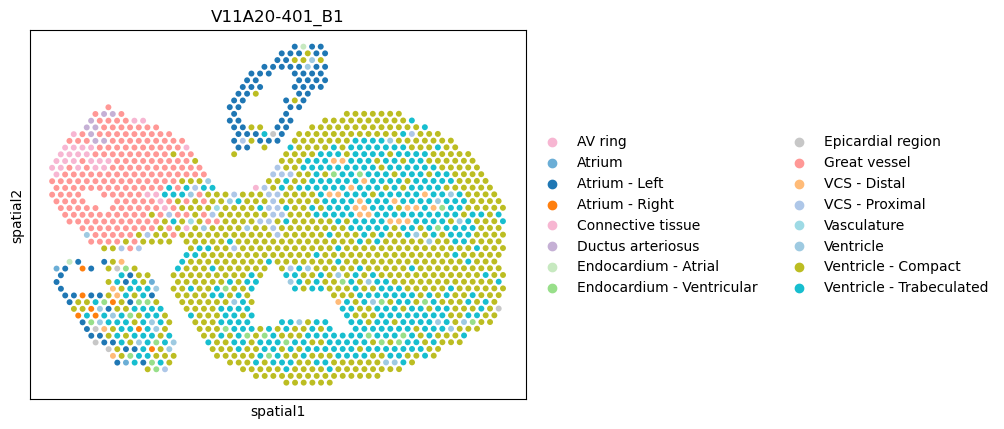

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


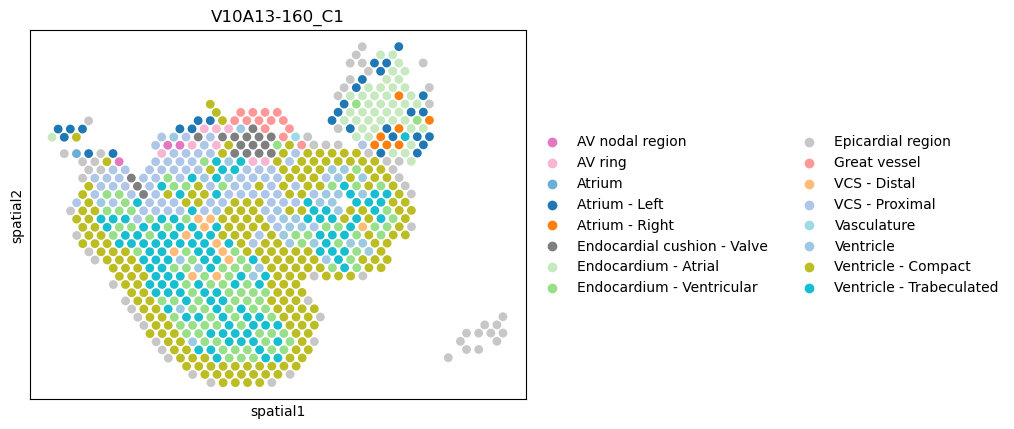

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


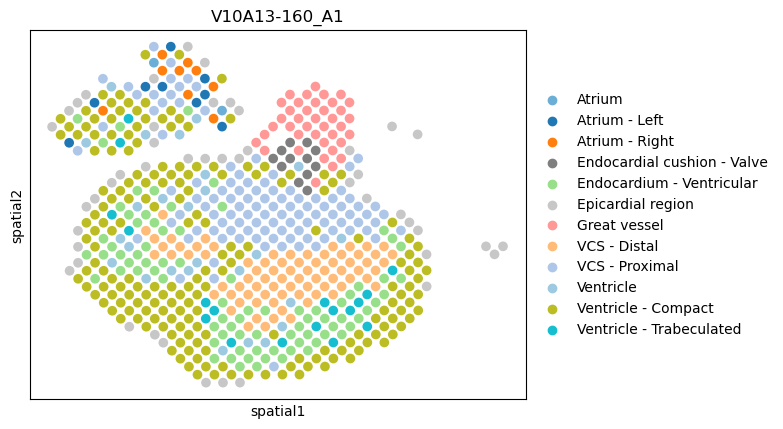

/opt/homebrew/Caskroom/miniforge/base/envs/tissuetypist/lib/python3.12/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


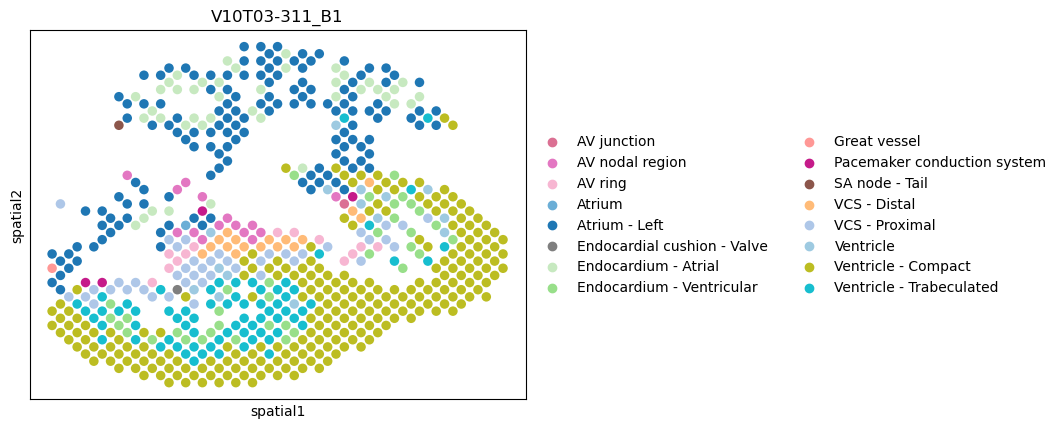

In [17]:
section_list = set(adata.obs["section.name"])
for section in section_list:
    slide = adata[adata.obs["section.name"]==section]
    sc.pl.embedding(slide, basis='spatial',
                    color="tt_final_label", palette=palette,
                  title=section)


## 6. Confidence score

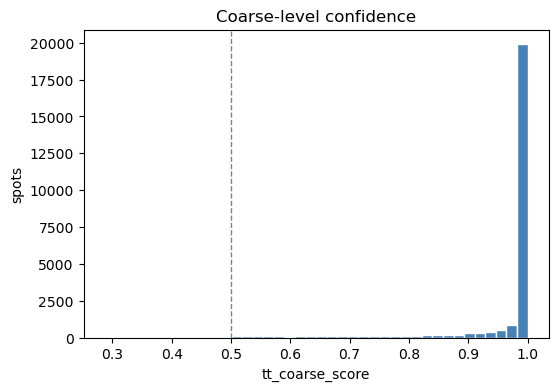

In [18]:
# Coarse-level confidence per spot. Spots with low coarse_score
# fall back to the coarse label; spots with high coarse_score resolve
# to a fine class.
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(adata.obs["tt_coarse_score"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("tt_coarse_score")
ax.set_ylabel("spots")
ax.set_title("Coarse-level confidence")
fig.savefig(OUTDIR / "coarse_score_hist.pdf", bbox_inches="tight")
plt.show()


## Where to next

- **Output column reference** — every `tt_*` column in
  [`docs/output-columns.md`](../docs/output-columns.md).
- **Niche hierarchy** — what each label means and how the multi-stage
  sub-models work, in [`docs/hierarchy.md`](../docs/hierarchy.md).
- **Imaging-based ST** — for Xenium / MERFISH / CosMx queries where
  retraining is required, see [`demo_merfish.ipynb`](demo_merfish.ipynb).
- **Evaluation** — to compute confusion matrices against ground truth
  labels, use `tissuetypist evaluate` (see
  [`docs/user-guide.md`](../docs/user-guide.md)).
